In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder


In [2]:
df_train = pd.read_parquet('train.parquet')
df_test = pd.read_parquet('test.parquet')

In [3]:
# df_user = df_train.groupby('userId').agg(
#     churn_flag=('churn_flag', 'max'),
#     pages=('page', lambda x: list(x))
# )

# all_pages = ['NextSong', 'Downgrade', 'Help', 'Home', 'Thumbs Up', 
#              'Add Friend', 'Thumbs Down', 'Add to Playlist', 'Logout',
#              'About', 'Settings', 'Save Settings', 'Cancel', 
#              'Cancellation Confirmation', 'Submit Downgrade', 'Roll Advert',
#              'Upgrade', 'Error', 'Submit Upgrade']

# for p in all_pages:
#     df_user[p] = df_user['pages'].apply(lambda x: int(p in x))

# X = df_user[all_pages]
# y = df_user['churn_flag']

# clf = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000)
# clf.fit(X, y)

# coef_table = pd.DataFrame({
#     'page': X.columns,
#     'coef': clf.coef_[0],
#     'odds_ratio': np.exp(clf.coef_[0])
# }).sort_values('odds_ratio', ascending=False)

# print(coef_table)


# Chi^2 test for checking feature significance (here status, but used previously for others)
# contingency = pd.crosstab(df_train['status'], df_train['churn_flag'])

# # run chi-square test
# chi2, p, dof, expected = chi2_contingency(contingency)

# print("Chi-square statistic:", chi2)
# print("Degrees of freedom:", dof)
# print("p-value:", p)



In [4]:
# Weights from Logistic Regression model (Done above)
churn_pages = {
    'Cancel': 7,
    'Cancellation Confirmation': 7,
    'Downgrade': 0.16,
    'Submit Upgrade': 0.14,
    'Upgrade': 0.03,
    'Settings': 0.02,
    'Submit Downgrade': 0.01
}

retain_pages = {
    'Save Settings': -0.0007,
    'Thumbs Down': -0.016,
    'About': -0.054,
    'Help': -0.058,
    'Add Friend': -0.158,
    'Add to Playlist': -0.383,
    'Roll Advert': -0.422,
    'Thumbs Up': -0.716,
    'Home': -1.423,
    'NextSong': -1.925
}

def compute_cumulative_risk(user_df):
    churn_score = 0
    not_churn_score = 0
    churn_list = []
    not_churn_list = []
        
    for page in user_df['page']:
        churn_score += churn_pages.get(page, 0)
        not_churn_score += retain_pages.get(page, 0)
        churn_list.append(churn_score)
        not_churn_list.append(not_churn_score)
        
    user_df['churn_risk_score'] = churn_list
    user_df['not_churn_score'] = not_churn_list
    return user_df


def feature_engineering(df):
    df['churn_flag'] = ((df['auth'] == 'Cancelled') | 
                        (df['page'] == 'Cancellation Confirmation')).astype(int)
    
    df['ts'] = pd.to_datetime(df['ts'], unit='ms')
    df = df.sort_values(['userId', 'ts'])
    
    df['churn_risk_score'] = 0.0
    df['not_churn_score'] = 0.0
    df['level'] = df['level'].map({'free': 0, 'paid': 1})
    df['timeInSession'] = df.groupby('userId')['ts'].transform(lambda x: (x - x.min()).dt.total_seconds())
    df['timeSinceRegistered'] = (df['ts'] - df['registration']).dt.total_seconds()

    feats_kept = ['status', 'level', 'userId', 'itemInSession', 'timeSinceRegistered', 
                  'not_churn_score', 'churn_risk_score', 'timeInSession']
    
    df = df.groupby('userId').apply(compute_cumulative_risk)
    df_seq = df[feats_kept + ['churn_flag']].copy()

    return df_seq

In [5]:
df_train = feature_engineering(df_train)
df_test = feature_engineering(df_test)

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [6]:
df_train.head()

,status,level,userId,itemInSession,timeSinceRegistered,not_churn_score,churn_risk_score,timeInSession,churn_flag
0,200,0,1000025,0,7255761.0,-1.423,0.0,0.0,0
1,200,0,1000025,1,7255956.0,-3.348,0.0,195.0,0
2,200,0,1000025,2,7256207.0,-5.273,0.0,446.0,0
3,200,0,1000025,3,7256430.0,-7.198,0.0,669.0,0
4,200,0,1000025,4,7256623.0,-9.123,0.0,862.0,0


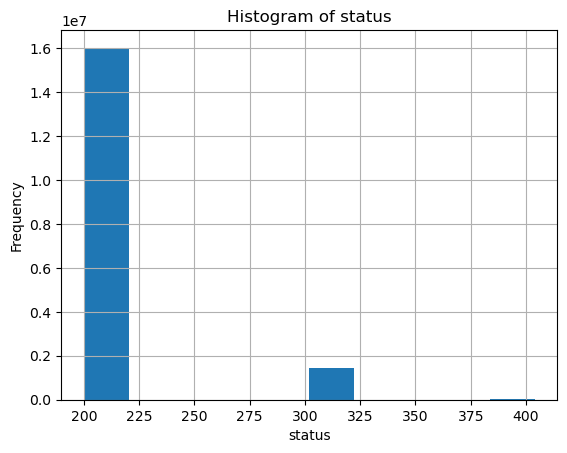

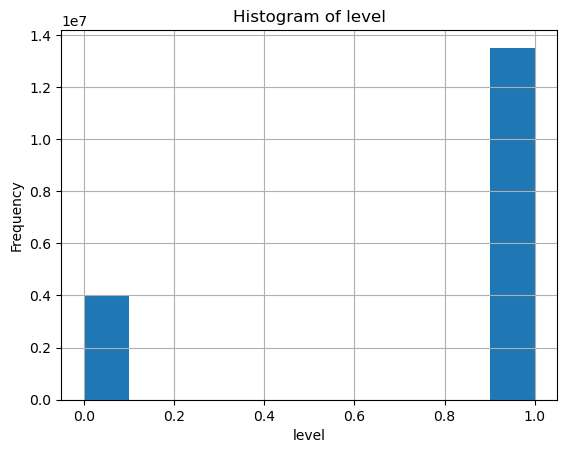

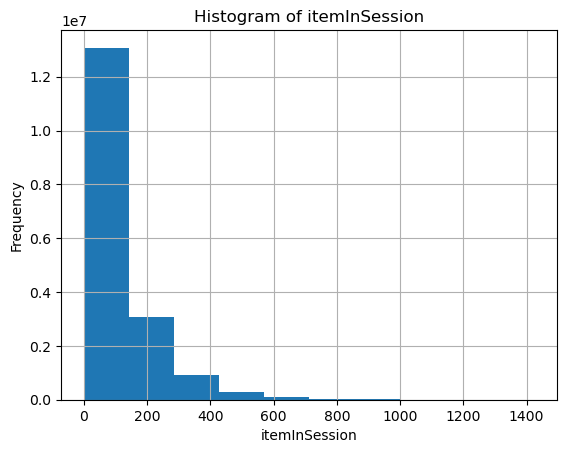

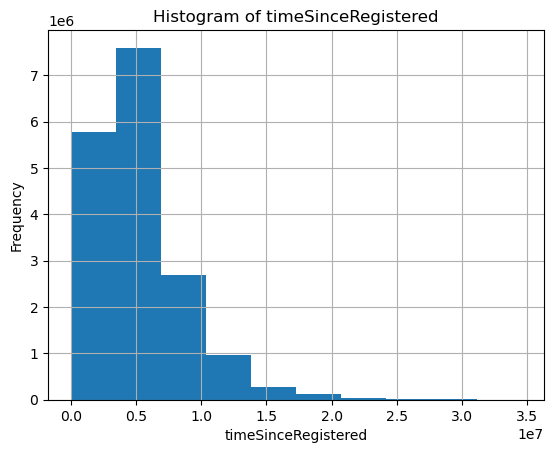

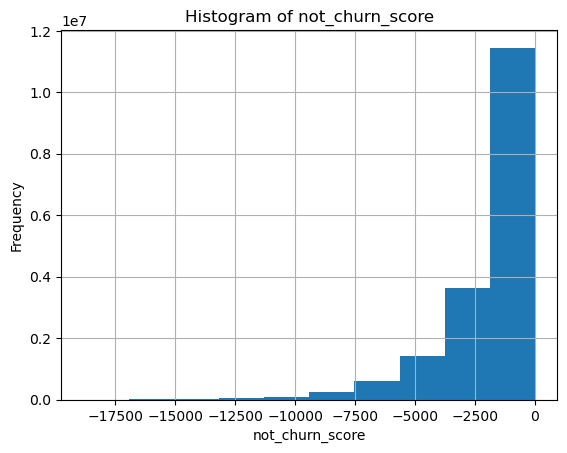

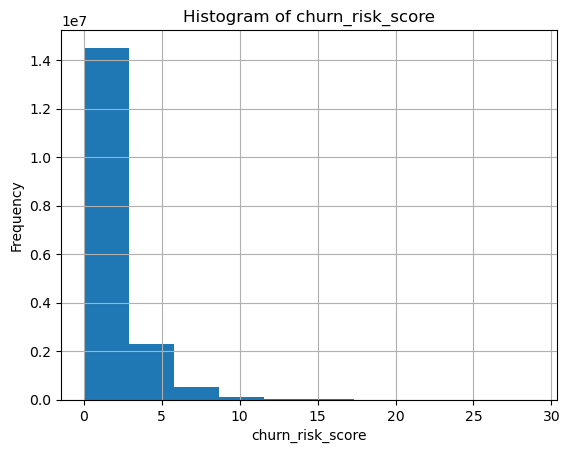

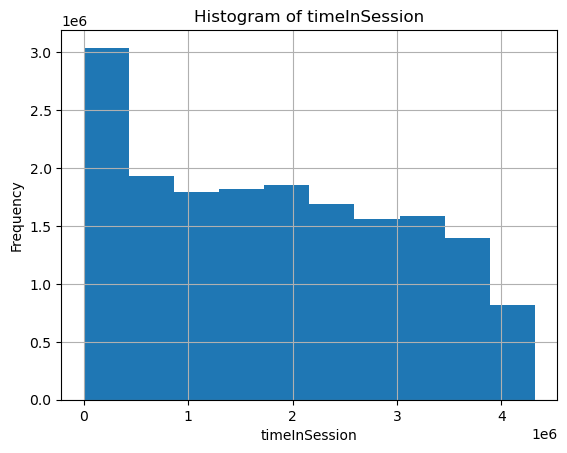

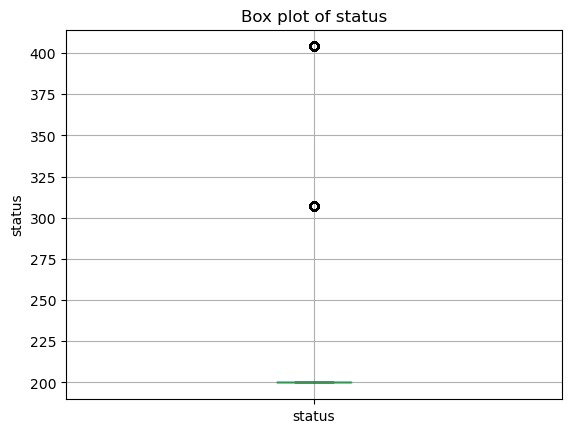

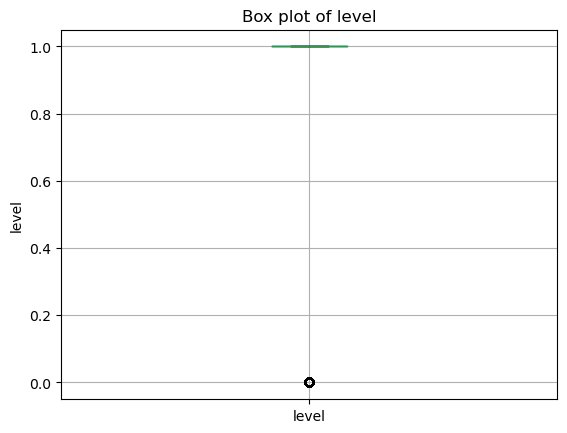

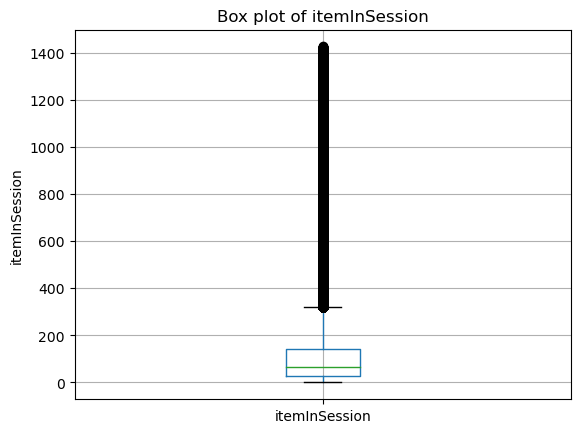

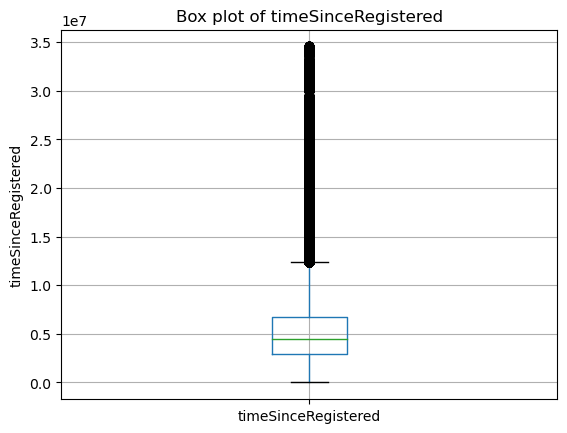

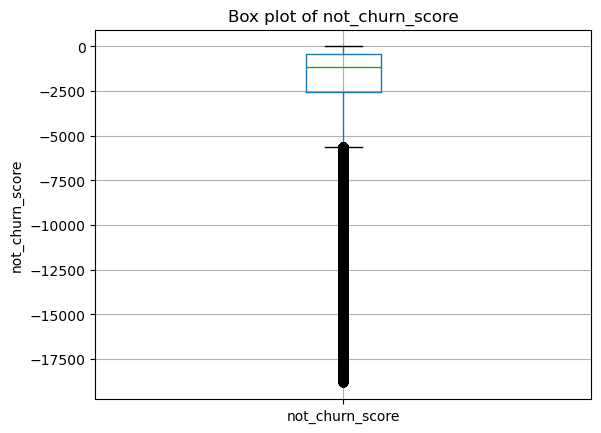

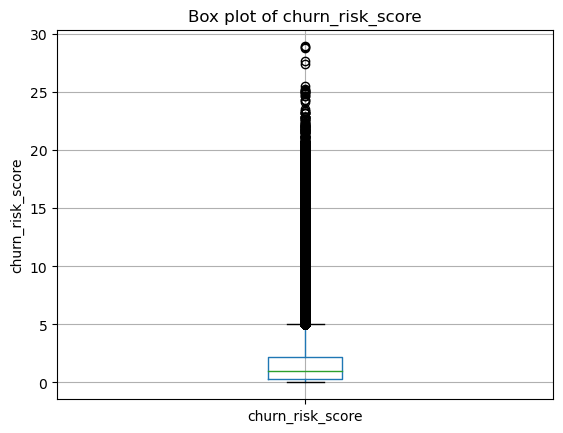

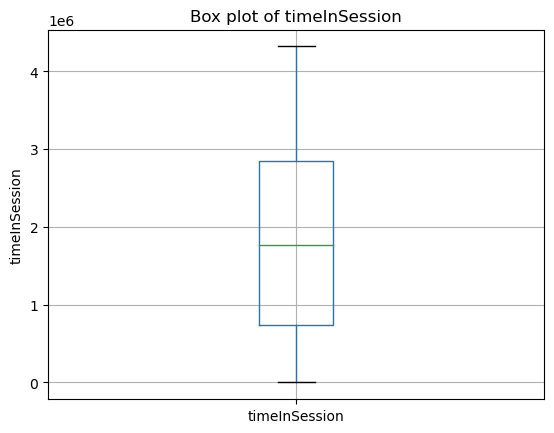

In [7]:
# Basic and Naive EDA
num_cols = df_train.select_dtypes(include=["int64", "float64"]).columns

# Histograms
for col in num_cols:
    plt.figure()
    df_train[col].hist()
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# Box plots
for col in num_cols:
    plt.figure()
    df_train.boxplot(column=col)
    plt.title(f"Box plot of {col}")
    plt.ylabel(col)
    plt.show()

In [ ]:
models = {
    "logistic_regression": LogisticRegression(random_state=42, max_iter=10000),
    "decision_tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random_forest": RandomForestClassifier(
        n_estimators=150, max_depth=4, random_state=42
    ),
    "GBDT": GradientBoostingClassifier(n_estimators=150, max_depth=4, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=200, max_depth=5, random_state=42),
    "ridge_regression": RidgeClassifier(random_state=42),
    "knn": KNeighborsClassifier(n_neighbors=5),
}

In [ ]:
y_train = df_train["churn_flag"]
X_train = df_train.drop(columns=["churn_flag", "userId"])
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)


In [ ]:
train_scores = []
test_scores = []
recall_test_scores = []

model_names = models.keys()

for model in model_names:
    print("For Model:", model)

    models[model].fit(X_train, y_train)

    print("For Training Set:")

    y_train_pred = models[model].predict(X_train)

    f1_train = f1_score(y_train, y_train_pred, average="macro")
    print("Macro F1 Score:", f1_train)

    print("Confusion Matrix:")
    confusion_matrix = metrics.confusion_matrix(y_train, y_train_pred)
    cm_display = metrics.ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix, display_labels=[False, True]
    )
    cm_display.plot()
    plt.show()

    print("For Test Set:")

    y_test_pred = models[model].predict(X_val)

    f1_test = f1_score(y_val, y_test_pred, average="macro")
    print("Macro F1 Score:", f1_test)

    recall_test_score = recall_score(y_val, y_test_pred, average="macro")

    print("Confusion Matrix:")
    confusion_matrix = metrics.confusion_matrix(y_val, y_test_pred)
    cm_display = metrics.ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix, display_labels=[False, True]
    )
    cm_display.plot()
    plt.show()

    train_scores.append(f1_train)
    test_scores.append(f1_test)
    recall_test_scores.append(recall_test_score)



In [ ]:
Tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
gbdt_model = GradientBoostingClassifier(n_estimators=150, max_depth=4, random_state=42)

Tree_model.fit(X_train, y_train)
gbdt_model.fit(X_train, y_train)

y_pred_proba_tree = [x[1] for x in Tree_model.predict_proba(X_val)]
y_pred_proba_gbdt = [x[1] for x in gbdt_model.predict_proba(X_val)]
y_pred_proba_tree = np.array(y_pred_proba_tree)
y_pred_proba_gbdt = np.array(y_pred_proba_gbdt)


y_pred_proba = (y_pred_proba_tree + y_pred_proba_gbdt) / 2.0

y_pred = np.where(y_pred_proba > 0.4, 1, 0)

f1 = f1_score(y_val, y_pred, average="macro")
print("Macro F1 Score:", f1)

recall = recall_score(y_val, y_pred, average="macro")
print("Macro Recall Score:", recall)

print("Confusion Matrix:")
confusion_matrix = metrics.confusion_matrix(y_val, y_pred)
cm_display = metrics.ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix, display_labels=[False, True]
)
cm_display.plot()
plt.show()

In [ ]:



tree_scores = cross_val_score(Tree_model, X_train, y_train, cv=5, scoring="f1_macro")
#gbdt_scores = cross_val_score(gbdt_model, X_train, y_train, cv=5, scoring="f1_macro")
print("Decision Tree CV Macro F1 Scores:", tree_scores)
#print("Gradient Boosting CV Macro F1 Scores:", gbdt_scores)


# faudrait faire deux predictions separées et apres submit les deux
# apres on peut aussi submit celle qui est combinée
